EXERCICE 0 (0 PT)
Perform a GET request to https://www.leboncoin.fr to retrieve the HTML homepage.
You must use an user agent to do so, as basic web security prevent HTTP requests from unknown web
browser.

In [43]:
import requests
from bs4 import BeautifulSoup

url="https://ci.coinafrique.com/"

headers= {
    "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/79.0.3945.74 Safari/537.36 Edg/79.0.309.43"
}
response=requests.get(url, headers=headers)
# print(response)

if response.status_code==200:
    soup= BeautifulSoup(response.text, "html.parser")
    print(response.status_code)
    



200


EXERCICE 1 (10 PT)
With the help of the Exercice0, and the User-Agent:
Create a function get_ps5_prices() that returns data from Playstation 5 game console sold on the website
using BeautifulSoup python library.
Route : /recherche?category=43&text=ps5
You must retrieve for each ads
- the title
- the price of the article (sellers may not have set a price for the article, put 0 instead)
- the date of when it was posted as ISO8601 format
- the city
- the postal code
Store all the data into a pandas dataframe.
Do only the first page (no need to go to page 2. . . .3. . . ..4)

In [ ]:

import pandas as pd
import requests
from bs4 import BeautifulSoup
import dateparser


def get_ps5_prices():


    url="https://ci.coinafrique.com/search?sort_by=relevance&keyword=console+playstation+5&category=25&price_min=200000"

    headers= {
        "User-Agent":"Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/79.0.3945.74 Safari/537.36 Edg/79.0.309.43"
    }
    response=requests.get(url, headers=headers)
    # print(response)

    reponse=[]
    if response.status_code==200:
        soup= BeautifulSoup(response.text, "html.parser")
        # print(soup)
        # quote_elements=soup.select("p")
        title=soup.find_all("p", class_="ad__card-description")
        date=soup.find_all("div", class_="card-title ad__card-timesince")
        city=soup.find_all("p", class_="ad__card-location")
        price=soup.find_all("p", class_="ad__card-price")
  
        
        # print(quote_elements)
        for a,b,c,d in zip (title,price,date,city):
            # print(a.get_text(),b.get_text(),dateparser.parse(c.get_text()),d.get_text().replace("location_on", ""))
            
            reponse.append({
                "title":a.get_text(),
                "price":b.get_text(),
                "date":dateparser.parse(c.get_text()),
                "city":d.get_text().replace("location_on", "")
            })
    dataf=pd.DataFrame(reponse)
    return dataf

get_ps5_prices()

,title,price,date,city
0,Console PlayStation 5 Sony,430 000CFA,2025-09-20 20:13:58.694445,"Yopougon, Abidjan, Côte d'Ivoire"
1,PlayStation 5 Slim,430 000CFA,2025-09-10 20:13:58.695119,"Yopougon, Abidjan, Côte d'Ivoire"
2,PlayStation 5 Slim,430 000CFA,2025-09-10 20:13:58.695708,"Yopougon, Abidjan, Côte d'Ivoire"
3,PlayStation 5,250 000CFA,2025-09-06 20:13:58.696289,"Abidjan, Côte d'Ivoire"
4,Playstation 5 Slim standard,450 000CFA,2025-09-03 20:13:58.696852,"Abidjan, Côte d'Ivoire"
...,...,...,...,...
79,PlayStation 5,605 000CFA,2022-09-26 20:13:58.741439,"Abidjan, Côte d'Ivoire"
80,Playstation 5,600 000CFA,2022-09-26 20:13:58.741995,"Treichville, Abidjan, Côte d'Ivoire"
81,PlayStation 5,615 000CFA,2022-09-26 20:13:58.742540,"Abidjan, Côte d'Ivoire"
82,PlayStation 5,250 000CFA,2022-09-26 20:13:58.743080,"Marcory, Abidjan, Côte d'Ivoire"


EXERCISE 02 (5PT)
Rather than exporting the pandas dataframe into SQL database, export it as a file stored on your computer.
This is called serialization.
Export your data using pickle, name the file ps5-dataframe.pickle
Create a loop that call get_ps5_prices function every 5 minutes using time.sleep(300)
Only if a new article was published as compared to the previous iteration, no duplicate data, export it again.

In [ ]:
import pickle
import time
data=get_ps5_prices()

try:
      
    with open("ps5-dataframe.pickle", "rb")  as file:
        loaded_data=pickle.load(file)
        print("file exists.")
    

except FileNotFoundError:
    with open("ps5-dataframe.pickle","wb") as file:
            pickle.dump(data, file)
            print("file doesn't exist, new is created")



while True:
    
    data    
    if len(data)>len(loaded_data):
        with open("ps5-dataframe.pickle","wb") as file:
            pickle.dump(data, file)
        print("new article therefore adds the old file has been replaced by the new one")
    else:
        print("no new articles added") 
    time.sleep(300)

file exists.
no new articles added


KeyboardInterrupt: 

EXERCISE 03 (5PT)
Create a new notebook call ex03
Create loop. Every 5 minutes, open ps5-dataframe.pickle in read-only mode in order to have your pandas
dataframe back.
Using Seaborn, box plot the price for each day.

file exists.


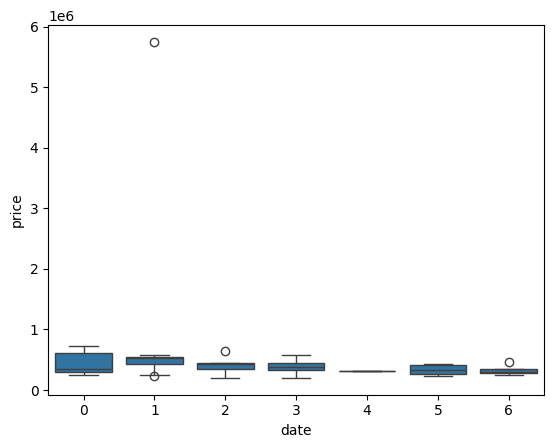

In [45]:
import seaborn as sns
from datetime import datetime

with open("ps5-dataframe.pickle", "rb")  as file:
    loaded_data=pickle.load(file)
    print("file exists.")
    days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
    sns.boxplot(loaded_data,x=loaded_data["date"].apply(lambda date:datetime.strptime(str(date), "%Y-%m-%d %H:%M:%S.%f").weekday()),y=loaded_data["price"].apply(lambda price: int(price.replace("CFA", "").replace(" ", ""))))
       
            
            

